Data Migration: SQL Server to Postgres

In [ ]:
import os
import pandas as pd 
import pyodbc
import psycopg2
from psycopg2.extras import execute_values   
from psycopg2 import sql
from dotenv import load_dotenv


# 1. Load credentials

In [20]:
load_dotenv()

True

In [3]:
sql_host = os.getenv("SQL_SERVER_HOST")
sql_db = os.getenv("SQL_SERVER_DB")
sql_user = os.getenv("SQL_SERVER_USER")


In [4]:
print(f"SQL_SERVER_HOST: {sql_host}")
print(f"SQL_SERVER_DB: {sql_db}")
print(f"SQL_SERVER_USER: {sql_user}")


SQL_SERVER_HOST: SOFONIAS\SQLEXPRESS
SQL_SERVER_DB: TransactionDB_UAT
SQL_SERVER_USER: windows


In [5]:
pg_host = os.getenv("POSTGRESQL_HOST")
pg_db = os.getenv("POSTGRESQL_DB")   
pg_user = os.getenv("POSTGRESQL_USER")
pg_password = os.getenv("POSTGRESQL_PASSWORD")
pg_port = os.getenv("POSTGRESQL_PORT")


In [6]:
print(f"POSTGRESQL_HOST: {pg_host}")
print(f"POSTGRESQL_DB: {pg_db}")
print(f"POSTGRESQL_USER: {pg_user}") 
print(f"POSTGRESQL_PASSWORD: {pg_password}")
print(f"POSTGRESQL_PORT: {pg_port}")

POSTGRESQL_HOST: localhost
POSTGRESQL_DB: transactiondb_uat
POSTGRESQL_USER: postgres
POSTGRESQL_PASSWORD: Qwerty-1029
POSTGRESQL_PORT: 5433


# 2. Connect to SQL Server

In [7]:
print("connecting to SQL Server...")
print(f"   SERVER: {sql_host}")
print(f"   DATABASE: {sql_db}")

connecting to SQL Server...
   SERVER: SOFONIAS\SQLEXPRESS
   DATABASE: TransactionDB_UAT


In [8]:
try:
    sql_conn_string = (
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={sql_host};"
        f"DATABASE={sql_db};"
        f"UID={sql_user};"
        f"Trusted_Connection=yes;"
    )
    sql_conn = pyodbc.connect(sql_conn_string)
    sql_cursor = sql_conn.cursor()
    print("Successfully connected to SQL Server!")
except Exception as e:
    print("Error connecting to SQL Server:")
    print(e)
    

Successfully connected to SQL Server!


# 3. Connect to PostgreSQL

In [9]:
print("connecting to PostgreSQL...")
print(f"   SERVER: {pg_host}")
print(f"   DATABASE: {pg_db}")

connecting to PostgreSQL...
   SERVER: localhost
   DATABASE: transactiondb_uat


In [10]:
try:
    # First, connect to the default postgres database to check/create target DB
    pg_admin_conn = psycopg2.connect(
        host=pg_host,
        database="postgres",
        user=pg_user,
        password=pg_password,
        port=pg_port
    )
    pg_admin_conn.autocommit = True
    pg_admin_cursor = pg_admin_conn.cursor()
    
    # Check if target database exists
    pg_admin_cursor.execute(
        "SELECT 1 FROM pg_database WHERE datname = %s",
        (pg_db,)
    )
    
    if not pg_admin_cursor.fetchone():
        print(f"Creating database '{pg_db}'...")
        pg_admin_cursor.execute(
            sql.SQL("CREATE DATABASE {};").format(sql.Identifier(pg_db))
        )
        print(f"✓ Database '{pg_db}' created successfully.")
    
    pg_admin_cursor.close()
    pg_admin_conn.close()

    # Now connect to the target database
    pg_conn = psycopg2.connect(
        host=pg_host,
        database=pg_db,
        user=pg_user,
        password=pg_password,
        port=pg_port
    )
    pg_cursor = pg_conn.cursor()
    pg_cursor.execute("SELECT version();")
    pg_version = pg_cursor.fetchone()[0]
    print(f"✓ Successfully connected to PostgreSQL!")
    print(f"  Version: {pg_version}")

except Exception as e:
    print(f"✗ Error with PostgreSQL: {e}")


✓ Successfully connected to PostgreSQL!
  Version: PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35226, 64-bit


# 4. Define the tables to migrate

### Migration order

- Categories (no dependencies)
- suppliers (no dependencies)
- customers (no dependencies)
- Products (depends on categories and suppliers)

In [29]:
tables_to_migrate = ['categories', 'Supplies', 'customers', 'products']
print (tables_to_migrate)

['categories', 'Supplies', 'customers', 'products']


In [30]:
print("tables_to_migrate:")
for i, table in enumerate(tables_to_migrate, start=1):
    print(f"{i}. {table}")

    total_no_tbls = len(tables_to_migrate)
    print(f"Total number of tables to migrate: {total_no_tbls}")

tables_to_migrate:
1. categories
Total number of tables to migrate: 4
2. Supplies
Total number of tables to migrate: 4
3. customers
Total number of tables to migrate: 4
4. products
Total number of tables to migrate: 4


# 5. Run pre-migration check

In [31]:
print('=' * 50)
print(">>> Row Counts")
print('=' * 50)

>>> Row Counts


In [32]:
baseline_counts = {}


try:   
    for table in tables_to_migrate:
        row_count_query = f"SELECT COUNT(*) as total_rows FROM {table}"
        sql_cursor.execute(row_count_query)
        count = sql_cursor.fetchone()[0]
        

        baseline_counts[table] = count
        print(f"{table:15} {count:>12} rows")

    total_rows = sum(baseline_counts.values())
    print(f"{'-' * 30}")
    print(f"{'total':15} {total_rows:>12} rows")
    print(f"\n Baseline captured! ")


        
except Exception as e:
    print(f"Error occurred while fetching row counts: {e}")
    raise

categories                 8 rows
Supplies                5003 rows
customers              10003 rows
products              150003 rows
------------------------------
total                 165017 rows

 Baseline captured! 


In [33]:
print("-" * 50)
print(">>> Null counts (before migration)")
print("-" * 50)


--------------------------------------------------
>>> Null counts (before migration)
--------------------------------------------------


In [34]:
try:
    sql_cursor.execute("""SELECT COUNT(*) AS MissingProductFK
FROM dbo.Supplies s
LEFT JOIN dbo.Products p ON s.ProductID = p.ProductID
WHERE p.ProductID IS NULL;""")
    null_count = sql_cursor.fetchone()[0]
    print(f"Supplies: {null_count} null values in ProductID")


    sql_cursor.execute("""SELECT COUNT(*) AS MissingCategoryInProducts
    FROM dbo.Products p
    LEFT JOIN dbo.Categories c ON p.CategoryID = c.CategoryID
    WHERE c.CategoryID IS NULL;""")
    null_count = sql_cursor.fetchone()[0]
    print(f"Products: {null_count} null values in CategoryID")


    sql_cursor.execute("""SELECT COUNT(*) AS MissingCategoryInSupplies
FROM dbo.Supplies s
LEFT JOIN dbo.Categories c ON s.CategoryID = c.CategoryID
WHERE c.CategoryID IS NULL;""")
    null_count = sql_cursor.fetchone()[0]
    print(f"Supplies: {null_count} null values in CategoryID")

    

    sql_cursor.execute("""SELECT COUNT(*) AS NegativePriceCount
FROM dbo.Products
WHERE Price < 0;""")
    null_count = sql_cursor.fetchone()[0]
    print(f"Products: {null_count} negative prices")



    sql_cursor.execute("""SELECT s.SupplyID, s.ProductID
FROM dbo.Supplies s
LEFT JOIN dbo.Products p ON s.ProductID = p.ProductID
WHERE p.ProductID IS NULL;
""")
    missing_product_ids = sql_cursor.fetchall()
    if missing_product_ids:
        print("Supplies with missing ProductID references:")
        for supply_id, product_id in missing_product_ids:
            print(f"SupplyID: {supply_id}, ProductID: {product_id}")
    else:
        print("No Supplies with missing ProductID references found.")



    sql_cursor.execute("""SELECT s.SupplyID, s.CategoryID
FROM dbo.Supplies s
LEFT JOIN dbo.Categories c ON s.CategoryID = c.CategoryID
WHERE c.CategoryID IS NULL;
""")
    missing_category_ids = sql_cursor.fetchall()
    if missing_category_ids:
        print("Supplies with missing CategoryID references:")
        for supply_id, category_id in missing_category_ids:
            print(f"SupplyID: {supply_id}, CategoryID: {category_id}")
    else:
        print("No Supplies with missing CategoryID references found.") 



    sql_cursor.execute("""SELECT SKU, COUNT(*) cnt FROM dbo.Products GROUP BY SKU HAVING COUNT(*) > 1;
SELECT Email, COUNT(*) cnt FROM dbo.Customers GROUP BY Email HAVING COUNT(*) > 1;
""")
    duplicate_skus = sql_cursor.fetchall()
    if duplicate_skus:
        print("Duplicate SKUs in Products:")
        for sku, count in duplicate_skus:
            print(f"SKU: {sku}, Count: {count}")
    else:
        print("No duplicate SKUs found in Products.")



    duplicate_emails = sql_cursor.fetchall()
    if duplicate_emails:
        print("Duplicate Emails in Customers:")
        for email, count in duplicate_emails:
            print(f"Email: {email}, Count: {count}")
    else:
        print("No duplicate Emails found in Customers.")



    sql_cursor.execute("""-- min/max/avg
SELECT MIN(Price) MinPrice, MAX(Price) MaxPrice, AVG(Price) AvgPrice FROM dbo.Products;
-- approximate 1st and 99th percentiles (SQL Server 2012+)
SELECT
  PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY Price) OVER () AS P1,
  PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY Price) OVER () AS P99
FROM dbo.Products;
""")
    price_stats = sql_cursor.fetchone()
    print(f"Price stats - Min: {price_stats[0]}, Max: {price_stats[1]}, Avg: {price_stats[2]}")







except Exception as e:
    print(f"Error occurred while fetching null counts: {e}")
    

Supplies: 0 null values in ProductID
Products: 0 null values in CategoryID
Supplies: 0 null values in CategoryID
Products: 0 negative prices
No Supplies with missing ProductID references found.
No Supplies with missing CategoryID references found.
No duplicate SKUs found in Products.
No duplicate Emails found in Customers.
Price stats - Min: 5.00, Max: 999.97, Avg: 503.121271


# 6. Get table schema

In [35]:
print("=" * 50)
print(">>> ANALYZE TABLE SCHEMA")
print("=" * 50)

>>> ANALYZE TABLE SCHEMA


In [36]:
table_schemas = {}


try:    
    for table in tables_to_migrate:
        schema_query = f"""
        SELECT 
            COLUMN_NAME, 
            DATA_TYPE, 
            CHARACTER_MAXIMUM_LENGTH, 
            IS_NULLABLE
        FROM INFORMATION_SCHEMA.COLUMNS
        WHERE TABLE_NAME = '{table}'
        order by ORDINAL_POSITION;
        """

        sql_cursor.execute(schema_query)
        columns = sql_cursor.fetchall()
        
        table_schemas[table] = columns
        
        print(f"Schema for {table}:")
        for col in columns:
            print(f"  - {col[0]}: {col[1]}({col[2]}) Nullable: {col[3]}")
        print("\n")
except Exception as e:
    print(f"Error occurred while fetching table schemas: {e}")

Schema for categories:
  - CategoryID: int(None) Nullable: NO
  - Name: nvarchar(100) Nullable: NO
  - Description: nvarchar(400) Nullable: YES


Schema for Supplies:
  - SupplyID: bigint(None) Nullable: NO
  - ProductID: bigint(None) Nullable: NO
  - CategoryID: int(None) Nullable: NO
  - SupplierName: nvarchar(200) Nullable: NO
  - Quantity: int(None) Nullable: NO
  - UnitCost: decimal(None) Nullable: NO
  - ReceivedAt: datetime2(None) Nullable: NO


Schema for customers:
  - CustomerID: bigint(None) Nullable: NO
  - FirstName: nvarchar(100) Nullable: NO
  - LastName: nvarchar(100) Nullable: NO
  - Email: nvarchar(255) Nullable: YES
  - Phone: nvarchar(50) Nullable: YES
  - CreatedAt: datetime2(None) Nullable: NO
  - IsActive: bit(None) Nullable: NO


Schema for products:
  - ProductID: bigint(None) Nullable: NO
  - SKU: nvarchar(50) Nullable: NO
  - Name: nvarchar(200) Nullable: NO
  - CategoryID: int(None) Nullable: NO
  - Price: decimal(None) Nullable: NO
  - CreatedAt: datetime2(

# 7. Define data type mappings
 

In [37]:
print("=" * 50)
print(">>> DATA TYPE MAPPING")
print("=" * 50)

>>> DATA TYPE MAPPING


In [38]:
type_mappings = {
    'bit': 'BOOLEAN',
    'tinyint': 'SMALLINT',
    'smallint': 'SMALLINT',
    'int': 'INTEGER',
    'bigint': 'BIGINT',
    'decimal': 'NUMERIC',
    'numeric': 'NUMERIC',
    'money': 'NUMERIC(19,4)',
    'smallmoney': 'NUMERIC(10,4)',
    'float': 'DOUBLE PRECISION',
    'real': 'REAL',
    'varchar': 'VARCHAR',
    'nvarchar': 'VARCHAR',
    'char': 'CHAR',
    'nchar': 'CHAR',
    'text': 'TEXT',
    'ntext': 'TEXT',
    'binary': 'BYTEA',
    'varbinary': 'BYTEA',
    'image': 'BYTEA',
    'uniqueidentifier': 'UUID',
    'xml': 'XML',
    'sql_variant': 'JSONB',
    'rowversion': 'BYTEA',        # SQL Server rowversion/timestamp -> binary token
    'timestamp': 'BYTEA',         # avoid confusion with PostgreSQL timestamp
    'datetime': 'TIMESTAMP',
    'smalldatetime': 'TIMESTAMP',
    'datetime2': 'TIMESTAMP',
    'datetimeoffset': 'TIMESTAMPTZ',
    'date': 'DATE',
    'time': 'TIME',
    'geography': 'GEOGRAPHY',     # requires PostGIS
    'geometry': 'GEOMETRY',       # requires PostGIS
    'hierarchyid': 'TEXT',        # no direct equivalent; store as TEXT or custom type
    'sysname': 'VARCHAR(128)',    # SQL Server system name type
    'variant': 'JSONB'            # alias mapping if encountered
}


In [39]:
print(f"SQL Server to PostgreSQL data type mappings ")
print("-" * 50)
for sql_type, pg_type in type_mappings.items():
    print(f"  - {sql_type:15} --->      {pg_type}")

    


SQL Server to PostgreSQL data type mappings 
--------------------------------------------------
  - bit             --->      BOOLEAN
  - tinyint         --->      SMALLINT
  - smallint        --->      SMALLINT
  - int             --->      INTEGER
  - bigint          --->      BIGINT
  - decimal         --->      NUMERIC
  - numeric         --->      NUMERIC
  - money           --->      NUMERIC(19,4)
  - smallmoney      --->      NUMERIC(10,4)
  - float           --->      DOUBLE PRECISION
  - real            --->      REAL
  - varchar         --->      VARCHAR
  - nvarchar        --->      VARCHAR
  - char            --->      CHAR
  - nchar           --->      CHAR
  - text            --->      TEXT
  - ntext           --->      TEXT
  - binary          --->      BYTEA
  - varbinary       --->      BYTEA
  - image           --->      BYTEA
  - uniqueidentifier --->      UUID
  - xml             --->      XML
  - sql_variant     --->      JSONB
  - rowversion      --->      BYTEA
 

# 8. Create tables in postgreSQL

In [40]:
print("=" * 50 )
print(f"Create Tables in PostgreSQL")
print("=" * 50 )

Create Tables in PostgreSQL


In [41]:
try:
    for table in tables_to_migrate:
        schema = table_schemas[table]
        print(f"Creating table {table} in PostgreSQL...")
        pg_table = table.lower().replace('"', '""')  # simple naming convention; escape quotes

        # Drop existing table (qualified with public schema)
        pg_cursor.execute(f'DROP TABLE IF EXISTS public."{pg_table}" CASCADE;')

        column_fragments = []
        pk_columns = []

        for col in schema:
            # Support both short and extended column metadata tuples:
            # (name, type, char_max_len, is_nullable) or
            # (name, type, char_max_len, is_nullable, is_identity, default, is_primary, is_unique)
            col_name = str(col[0]).lower().replace('"', '""')
            sql_type = col[1] if len(col) > 1 else None
            char_max_len = col[2] if len(col) > 2 else None
            is_nullable = col[3] if len(col) > 3 else 'YES'
            is_identity = col[4] if len(col) > 4 else False
            default_expr = col[5] if len(col) > 5 else None
            is_primary = col[6] if len(col) > 6 else False
            is_unique = col[7] if len(col) > 7 else False

            # Normalize type token and map
            base_type = (str(sql_type).strip().lower() if sql_type else '')
            pg_type = type_mappings.get(base_type, None)

            # If original type included params like varchar(50) or decimal(10,2), try to extract them
            if pg_type is None and sql_type:
                import re
                m = re.match(r'([a-z0-9_]+)\s*\((.+)\)', str(sql_type).strip(), flags=re.IGNORECASE)
                if m:
                    base = m.group(1).lower()
                    params = m.group(2)
                    pg_base = type_mappings.get(base, 'TEXT')
                    if pg_base in ('VARCHAR', 'CHAR') and params:
                        pg_type = f"{pg_base}({params.split(',')[0].strip()})"
                    elif pg_base == 'NUMERIC' and params:
                        pg_type = f"NUMERIC({params})"
                    else:
                        pg_type = pg_base
                else:
                    pg_type = 'TEXT'
            if pg_type in ('VARCHAR', 'CHAR') and char_max_len:
                pg_type = f"{pg_type}({char_max_len})"

            # Build column SQL fragment as plain string (identifiers quoted)
            col_parts = [f'"{col_name}"', pg_type]

            if is_identity:
                # map SQL Server identity to Postgres identity
                col_parts.append("GENERATED BY DEFAULT AS IDENTITY")

            # Nullability
            if str(is_nullable).upper() == 'YES' or is_nullable is None:
                col_parts.append("NULL")
            else:
                col_parts.append("NOT NULL")

            # Default expression (basic conversions)
            if default_expr:
                d = str(default_expr).strip()
                d = d.replace('GETDATE()', 'CURRENT_TIMESTAMP').replace('SYSUTCDATETIME()', 'CURRENT_TIMESTAMP').replace('NEWID()', 'gen_random_uuid()')
                # remove surrounding parentheses if simple
                if d.startswith('(') and d.endswith(')'):
                    inner = d[1:-1].strip()
                    if not any(op in inner for op in [' ', '+', '-', '*', '/']):
                        d = inner
                col_parts.append("DEFAULT " + d)

            # Compose column fragment
            column_fragments.append(' '.join(col_parts))

            # Collect PK/unique info for table-level constraints
            if is_primary:
                pk_columns.append(col_name)
            if is_unique:
                # add unique constraint as table-level constraint
                column_fragments.append(f'UNIQUE ("{col_name}")')

        # Table-level primary key constraint
        table_constraints = []
        if pk_columns:
            pk_list = ', '.join([f'"{c}"' for c in pk_columns])
            table_constraints.append(f"PRIMARY KEY ({pk_list})")

        all_defs = ', '.join(column_fragments + table_constraints)
        create_table_sql = f'CREATE TABLE public."{pg_table}" ( {all_defs} );'

        pg_cursor.execute(create_table_sql)

    # commit via cursor's connection to persist DDL
    try:
        pg_cursor.connection.commit()
    except Exception:
        pass
except psycopg2.Error as e:
    print(f"PostgreSQL error occurred while creating tables: {e}") 
    pg_conn.rollback()  # rollback to clean state if DDL failed
    raise

except Exception as e:
    print(f"Error occurred while creating tables: {e}")


Creating table categories in PostgreSQL...
Creating table Supplies in PostgreSQL...
Creating table customers in PostgreSQL...
Creating table products in PostgreSQL...


# 9. Testing migration Table

In [42]:
print("=`" * 50 )
print(f">>> Testing migration Table")
print("=`" * 50 )   

=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`
>>> Testing migration Table
=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`=`


In [49]:
test_table = 'products'
pg_table = test_table.lower().replace('"', '""')

try:
    print("1. Read from SQL Server... ")
    extract_query = f"SELECT * FROM {pg_table}"
    test_df = pd.read_sql_query(extract_query, sql_conn)

    print(f"   - Rows read: {test_df.shape[0]}, Columns: {test_df.shape[1]}")

    print("2.  Transforming data types... ")
    for col in test_df.columns:
        if pd.api.types.is_datetime64_any_dtype(test_df[col]):
            test_df[col] = test_df[col].dt.tz_localize(None)
        elif pd.api.types.is_bool_dtype(test_df[col]):
            test_df[col] = test_df[col].astype(bool)
        elif pd.api.types.is_integer_dtype(test_df[col]):
            test_df[col] = test_df[col].astype('Int64')  # nullable integer
        elif pd.api.types.is_float_dtype(test_df[col]):
            test_df[col] = test_df[col].astype(float)
        elif pd.api.types.is_object_dtype(test_df[col]):
            test_df[col] = test_df[col].apply(lambda v: (v.replace(b'\x00', b'') if isinstance(v, (bytes, bytearray)) else str(v).replace('\x00','')) )


    print("   - Data types transformed for PostgreSQL compatibility")

    print("3. Load into PostgreSQL... ")
    columns = [c.lower() for c in test_df.columns]
    values = [tuple(x) for x in test_df.to_numpy()]
    cols_sql = ', '.join(f'"{c}"' for c in columns)

    # Empty the target table before inserting to avoid duplicate rows from reruns.
    pg_cursor.execute(f'TRUNCATE TABLE public."{pg_table}" RESTART IDENTITY CASCADE;')
    pg_conn.commit()

    insert_query = f'INSERT INTO public."{pg_table}" ({cols_sql}) VALUES %s'
    execute_values(pg_cursor, insert_query, values)

    print(f"   - Rows inserted: {len(values)}") 
    pg_conn.commit()

    print("4. Verifying row counts... ")
    pg_cursor.execute(f'SELECT COUNT(*) FROM public."{pg_table}";')
    pg_count = pg_cursor.fetchone()[0]
    sql_count = baseline_counts[test_table]

    if pg_count == sql_count:
        print("✓ Row counts match!")
    else:
        print("✗ Row counts do NOT match!")
        print(f"   - SQL Server count: {sql_count}")
        print(f"   - PostgreSQL count: {pg_count}") 

except Exception as e:
    print(f"Error during test migration: {e}")
    try:
        pg_conn.rollback()
    except Exception:
        pass


1. Read from SQL Server... 


C:\Users\Sofonn\AppData\Local\Temp\ipykernel_12560\416525560.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test_df = pd.read_sql_query(extract_query, sql_conn)


   - Rows read: 150003, Columns: 7
2.  Transforming data types... 
   - Data types transformed for PostgreSQL compatibility
3. Load into PostgreSQL... 
   - Rows inserted: 150003
4. Verifying row counts... 
✓ Row counts match!


# Migrate remaining Tables 

In [50]:
print("=" * 50)
print(">>> Migrating remaining tables")   
print("=" * 50)

>>> Migrating remaining tables


In [51]:
remaining_tables = [t for t in tables_to_migrate if t != test_table]

print(f"Remaining tables to migrate: {remaining_tables}\n")

for table in remaining_tables:
    pg_table = table.lower().replace('"', '""')
    
    print(f"{'=' * 50}")
    print(f"Migrating: {table}")
    print(f"{'=' * 50}")

    try:
        print(f"1. Read from SQL Server... ")
        extract_query = f"SELECT * FROM {table}"
        df = pd.read_sql_query(extract_query, sql_conn)

        print(f"   - Rows read: {df.shape[0]}, Columns: {df.shape[1]}")

        print("2.  Transforming data types... ")
        for col in df.columns:
            if pd.api.types.is_datetime64_any_dtype(df[col]):
                df[col] = df[col].dt.tz_localize(None)
            elif pd.api.types.is_bool_dtype(df[col]):
                df[col] = df[col].astype(bool)
            elif pd.api.types.is_integer_dtype(df[col]):
                df[col] = df[col].astype('Int64')  # nullable integer
            elif pd.api.types.is_float_dtype(df[col]):
                df[col] = df[col].astype(float)
            elif pd.api.types.is_object_dtype(df[col]):
                df[col] = df[col].astype(str)
        print("   - Data types transformed for PostgreSQL compatibility")

        print("3. Load into PostgreSQL... ")
        columns = [c.lower() for c in df.columns]
        values = [tuple(x) for x in df.to_numpy()]
        cols_sql = ', '.join(f'"{c}"' for c in columns)

        # Empty the target table before inserting to avoid duplicate rows from reruns.
        pg_cursor.execute(f'TRUNCATE TABLE public."{pg_table}" RESTART IDENTITY CASCADE;')
        pg_conn.commit()

        insert_query = f'INSERT INTO public."{pg_table}" ({cols_sql}) VALUES %s'
        execute_values(pg_cursor, insert_query, values)

        print(f"   - Rows inserted: {len(values)}") 
        pg_conn.commit()

        print("4. Verifying row counts... ")
        pg_cursor.execute(f'SELECT COUNT(*) FROM public."{pg_table}";')
        pg_count = pg_cursor.fetchone()[0]
        sql_count = baseline_counts[table]

        if pg_count == sql_count:
            print(f"✓ {table} migration successful! Row counts match: {pg_count}")
        else:
            print(f"✗ {table} migration warning - Row counts do NOT match!")
            print(f"   - SQL Server count: {sql_count}")
            print(f"   - PostgreSQL count: {pg_count}")
        print()
        
    except Exception as e:
        print(f"✗ Error migrating {table}: {e}")
        try:
            pg_conn.rollback()
        except Exception:
            pass
        print()


Remaining tables to migrate: ['categories', 'Supplies', 'customers']

Migrating: categories
1. Read from SQL Server... 
   - Rows read: 8, Columns: 3
2.  Transforming data types... 
   - Data types transformed for PostgreSQL compatibility
3. Load into PostgreSQL... 
   - Rows inserted: 8
4. Verifying row counts... 
✓ categories migration successful! Row counts match: 8

Migrating: Supplies
1. Read from SQL Server... 
   - Rows read: 5003, Columns: 7
2.  Transforming data types... 
   - Data types transformed for PostgreSQL compatibility
3. Load into PostgreSQL... 
   - Rows inserted: 5003
4. Verifying row counts... 
✓ Supplies migration successful! Row counts match: 5003

Migrating: customers
1. Read from SQL Server... 


C:\Users\Sofonn\AppData\Local\Temp\ipykernel_12560\1245128371.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(extract_query, sql_conn)
C:\Users\Sofonn\AppData\Local\Temp\ipykernel_12560\1245128371.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(extract_query, sql_conn)
C:\Users\Sofonn\AppData\Local\Temp\ipykernel_12560\1245128371.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(extract_query, sql_conn)


   - Rows read: 10003, Columns: 7
2.  Transforming data types... 
   - Data types transformed for PostgreSQL compatibility
3. Load into PostgreSQL... 
✗ Error migrating customers: A string literal cannot contain NUL (0x00) characters.



# 11. Run Post-migration validation

### --- 1. Row counts checks

##### Success: Matches SQL server

### -- 2. Data type checks


##### suceess: Matches SQL server

### -- 3. Primary key checks (duplicates)


#####  suceess: Matches SQL server



### -- 4. Referatial integrity checks


##### success: Matches SQL server


In [52]:
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.facecolor'] = '#f0f0f0'


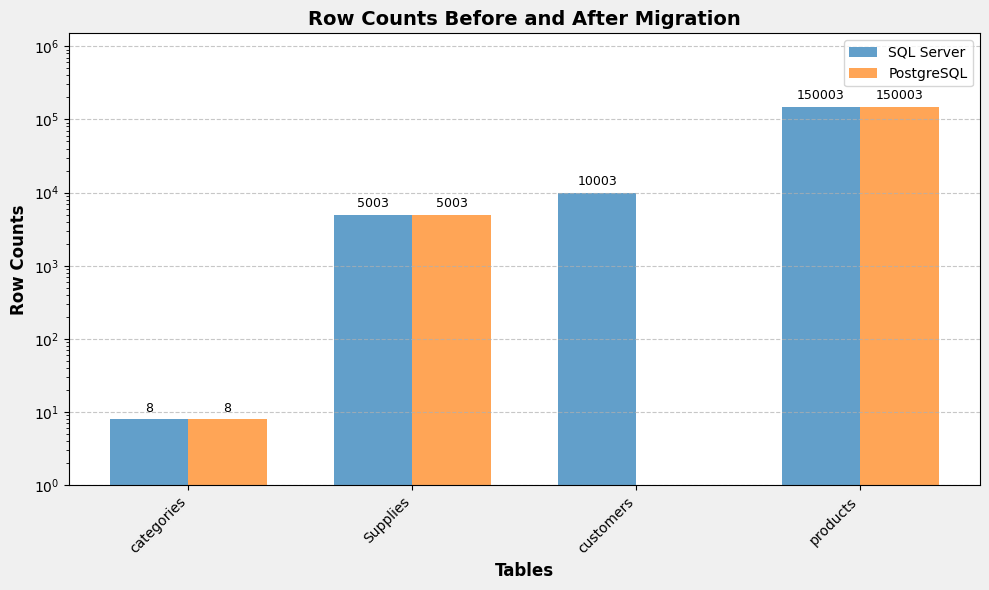

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
table_names = tables_to_migrate
sql_counts = [baseline_counts[table] for table in tables_to_migrate]
pg_counts = []
for table in tables_to_migrate:
    pg_cursor.execute(f'SELECT COUNT(*) FROM public."{table.lower()}";')
    pg_count = pg_cursor.fetchone()[0]
    pg_counts.append(pg_count)

x = range(len(table_names))
width = 0.35   

bar1 = ax.bar(x, sql_counts, width, label='SQL Server', color='#1f77b4', alpha=0.7)
bar2 = ax.bar([i + width for i in x], pg_counts, width, label='PostgreSQL', color='#ff7f0e', alpha=0.7 )

ax.set_xlabel('Tables', fontsize=12, fontweight='bold')
ax.set_ylabel('Row Counts', fontsize=12, fontweight='bold')

ax.set_title('Row Counts Before and After Migration', fontsize=14, fontweight='bold')
ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(table_names, rotation=45, ha='right', fontsize=10)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.bar_label(bar1, padding=3, fontsize=9)
ax.bar_label(bar2, padding=3, fontsize=9)

ax.set_yscale('log')  # Use logarithmic scale for better visibility of differences
ax.set_ylim(1, max(max(sql_counts), max(pg_counts)) * 10)  # Set y-axis limits for log scale

plt.tight_layout()
plt.show()